# 🔬 Wyckoff Pattern — Machine Learning Research
### CRISP-DM Framework | Machine Learning Only (No Deep Learning)

---
**CRISP-DM Phases:**
1. **Business Understanding** — เข้าใจโจทย์วิจัย Wyckoff
2. **Data Understanding** — สำรวจและทำความเข้าใจข้อมูล
3. **Data Preparation** — เตรียมข้อมูลและ Features
4. **Modeling** — สร้างและเทรนโมเดล ML
5. **Evaluation** — ประเมินผลและเปรียบเทียบ
6. **Deployment/Reporting** — Dashboard และ Research Output

---
**Wyckoff Events Detected:**
- **Accumulation**: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU
- **Distribution**: PSY, BC, AR, ST, UT, UTAD, SOW, LPSY

---
## 📋 Phase 1: Business Understanding
กำหนดวัตถุประสงค์งานวิจัยและเกณฑ์ความสำเร็จ

# ===== CRISP-DM Phase 1: Business Understanding =====

📌 วัตถุประสงค์:
   1. ตรวจจับ Wyckoff Event ด้วย Rule-Based Logic
   2. สร้าง ML Model จำแนก Event Label (Accumulation / Distribution)
   3. ทำนายทิศทางราคาหลังเกิด Event ล่วงหน้า 10 วัน
   4. วัด Win Rate ของสัญญาณแต่ละ Event
   5. Backtest เพื่อประเมินมูลค่าสัญญาณ

📌 เกณฑ์ความสำเร็จ:
   Classification Accuracy > 70%
   AUC-ROC > 0.60
   Win Rate ของ LPS/SOS > 55%
   ML Strategy Sharpe Ratio > 0.5

📌 โมเดลที่ใช้:
   Random Forest Classifier/Regressor
   Gradient Boosting (GBM)
   XGBoost
   Logistic Regression (Baseline)

---
## ⚙️ Phase 2: Data Understanding — Setup & Import

In [ ]:
# ===== IMPORTS (Machine Learning Only — No Deep Learning) =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)
plt.style.use('dark_background')
COLORS = {'accent': '#00D4FF', 'green': '#00FF88', 'red': '#FF4444',
          'yellow': '#FFD700', 'purple': '#BB86FC', 'orange': '#FF8C00'}

# Sklearn — Machine Learning only
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    mean_squared_error, mean_absolute_error, f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV

# Optional: SMOTE
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
    print('✅ imbalanced-learn (SMOTE) พร้อมใช้งาน')
except ImportError:
    HAS_SMOTE = False
    print('⚠️  imbalanced-learn ไม่ได้ติดตั้ง — ข้าม SMOTE')

# Optional: XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
    print(f'✅ XGBoost {xgb.__version__} พร้อมใช้งาน')
except ImportError:
    HAS_XGB = False
    print('⚠️  XGBoost ไม่ได้ติดตั้ง')

print('\n✅ Import สำเร็จ — Machine Learning Only Mode')

✅ imbalanced-learn (SMOTE) พร้อมใช้งาน
✅ XGBoost 3.1.3 พร้อมใช้งาน

✅ Import สำเร็จ — Machine Learning Only Mode
🚫 Deep Learning (LSTM/TensorFlow) ถูกปิดใช้งาน


In [2]:
# ===== โหลดข้อมูล =====
print("="*70)
print("   CRISP-DM Phase 2: DATA UNDERSTANDING — โหลดข้อมูล")
print("="*70)

file_path = "/Users/hilmanyusoh/Desktop/stock_pattern/data/ข้อมูลย้อนหลังของ ดัชนี SET 100.csv"
df = pd.read_csv(file_path, thousands=',', decimal='.')
df.columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct']
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

def convert_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.upper()
        if 'B' in vol_str: return float(vol_str.replace('B', '')) * 1e9
        if 'M' in vol_str: return float(vol_str.replace('M', '')) * 1e6
        if 'K' in vol_str: return float(vol_str.replace('K', '')) * 1e3
    return float(vol_str)

df['Volume'] = df['Volume'].apply(convert_volume)
df = df.dropna()
df = df[df['Volume'] > 0].reset_index(drop=True)

print(f'\n✅ โหลดข้อมูลสำเร็จ')
print(f'   จำนวนแถว : {len(df):,}')
print(f'   ช่วงเวลา  : {df["Date"].min().date()} ถึง {df["Date"].max().date()}')
print(f'   จำนวนปี  : {(df["Date"].max() - df["Date"].min()).days / 365:.1f} ปี')

print('\n📊 ตาราง: ข้อมูล 5 แถวแรก')
display(df.head())

print('\n📊 ตาราง: สถิติพื้นฐาน')
display(df[['Close','Open','High','Low','Volume']].describe().round(2))

# Missing values
missing = df.isnull().sum()
missing_df = pd.DataFrame({'Column': missing.index, 'Missing': missing.values,
                            'Pct (%)': (missing.values / len(df) * 100).round(2)})
print('\n📊 ตาราง: Missing Values')
display(missing_df)

   CRISP-DM Phase 2: DATA UNDERSTANDING — โหลดข้อมูล

✅ โหลดข้อมูลสำเร็จ
   จำนวนแถว : 3,554
   ช่วงเวลา  : 2011-08-16 ถึง 2026-03-13
   จำนวนปี  : 14.6 ปี

📊 ตาราง: ข้อมูล 5 แถวแรก


,Date,Close,Open,High,Low,Volume,Change_Pct
0,2011-08-16,1632.9000,1656.4500,1657.0000,1632.9000,1900000.0000,-0.98%
1,2011-08-17,1659.8400,1647.0200,1662.9300,1645.0300,2030000.0000,1.65%
2,2011-08-18,1654.8600,1669.8800,1676.6100,1653.0100,1960000.0000,-0.30%
3,2011-08-19,1621.0900,1627.6900,1638.6000,1616.0600,2320000.0000,-2.04%
4,2011-08-22,1619.7200,1620.2000,1621.1300,1592.8100,1890000.0000,-0.08%



📊 ตาราง: สถิติพื้นฐาน


,Close,Open,High,Low,Volume
count,3554.0000,3554.0000,3554.0000,3554.0000,3554.0000
mean,2096.2100,2097.6000,2108.6300,2084.2300,2326156216.6400
std,256.6800,257.2400,256.2500,257.3600,1095946391.5600
min,1284.8100,1297.0000,1315.9100,1266.0200,630350.0000
25%,1911.2900,1911.9000,1922.2800,1898.9800,1710000000.0000
50%,2127.8600,2130.2000,2142.2900,2115.8500,2160000000.0000
75%,2258.7400,2262.0100,2271.2700,2249.4600,2770000000.0000
max,2677.3900,2691.2300,2711.9600,2674.3100,16850000000.0000



📊 ตาราง: Missing Values


,Column,Missing,Pct (%)
0,Date,0,0.0000
1,Close,0,0.0000
2,Open,0,0.0000
3,High,0,0.0000
4,Low,0,0.0000
5,Volume,0,0.0000
6,Change_Pct,0,0.0000


---
## 🔧 Phase 3: Data Preparation — Feature Engineering

In [4]:
# ===== CRISP-DM Phase 3: Feature Engineering =====
print("="*70)
print("   CRISP-DM Phase 3: DATA PREPARATION — Feature Engineering")
print("="*70)

# --- Wyckoff Core Features ---
df['Spread']       = df['High'] - df['Low']
df['Close_Pos']    = (df['Close'] - df['Low']) / (df['Spread'] + 1e-6)
df['Lower_Shadow'] = df[['Open', 'Close']].min(axis=1) - df['Low']
df['Upper_Shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)
df['Vol_MA20']     = df['Volume'].rolling(20).mean()
df['Rel_Vol']      = df['Volume'] / (df['Vol_MA20'] + 1e-6)
df['Spread_MA20']  = df['Spread'].rolling(20).mean()
df['Rel_Spread']   = df['Spread'] / (df['Spread_MA20'] + 1e-6)
df['Price_Trend']  = df['Close'].diff(5)

# --- Trading Range (Support / Resistance) ---
window_tr = 50
df['Support_TR']    = df['Low'].rolling(window_tr).min().shift(1)
df['Resistance_TR'] = df['High'].rolling(window_tr).max().shift(1)
df['Dist_from_Sup'] = (df['Low'] - df['Support_TR']) / (df['Support_TR'] + 1e-6)
df['Dist_from_Res'] = (df['High'] - df['Resistance_TR']) / (df['Resistance_TR'] + 1e-6)

# --- Momentum & Trend ---
df['Return_1d']     = df['Close'].pct_change(1)
df['Return_5d']     = df['Close'].pct_change(5)
df['Return_10d']    = df['Close'].pct_change(10)
df['MA10']          = df['Close'].rolling(10).mean()
df['MA20']          = df['Close'].rolling(20).mean()
df['MA50']          = df['Close'].rolling(50).mean()
df['Price_vs_MA10'] = df['Close'] / (df['MA10'] + 1e-6) - 1
df['Price_vs_MA20'] = df['Close'] / (df['MA20'] + 1e-6) - 1
df['Price_vs_MA50'] = df['Close'] / (df['MA50'] + 1e-6) - 1
df['MA10_slope']    = df['MA10'].diff(3) / (df['MA10'].shift(3) + 1e-6)
df['MA20_slope']    = df['MA20'].diff(3) / (df['MA20'].shift(3) + 1e-6)

# --- RSI (14) ---
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-6)))
df['RSI_slope'] = df['RSI'].diff(3)

# --- Bollinger Bands ---
bb_mid = df['Close'].rolling(20).mean()
bb_std = df['Close'].rolling(20).std()
df['BB_Width']    = (2 * bb_std) / (bb_mid + 1e-6)
df['BB_Position'] = (df['Close'] - (bb_mid - 2*bb_std)) / (4*bb_std + 1e-6)

# --- MACD ---
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

# --- Volume Analysis ---
df['Vol_MA5']   = df['Volume'].rolling(5).mean()
df['Vol_Spike'] = df['Volume'] / (df['Vol_MA5'] + 1e-6)
df['Vol_trend'] = df['Volume'].pct_change(5)

# --- Candle Structure ---
df['Body_Size']       = abs(df['Close'] - df['Open']) / (df['Spread'] + 1e-6)
df['Is_Bullish']      = (df['Close'] > df['Open']).astype(int)
df['Shadow_Ratio']    = df['Lower_Shadow'] / (df['Upper_Shadow'] + 1e-6)

# --- Trading Range Position ---
tr_range = df['Resistance_TR'] - df['Support_TR'] + 1e-6
df['TR_Position']   = (df['Close'] - df['Support_TR']) / tr_range

# --- Volatility ---
df['ATR14']      = df['Spread'].rolling(14).mean()
df['ATR_ratio']  = df['Spread'] / (df['ATR14'] + 1e-6)
df['Volatility'] = df['Return_1d'].rolling(20).std()

print('\n✅ Feature Engineering เสร็จสิ้น')
print(f'   จำนวน Columns ทั้งหมด: {len(df.columns)}')

print('\n📊 ตาราง: Feature Summary')
feature_groups = {
    'Wyckoff Core': ['Spread','Close_Pos','Lower_Shadow','Upper_Shadow','Rel_Vol','Rel_Spread','Price_Trend'],
    'Trading Range': ['Dist_from_Sup','Dist_from_Res','TR_Position'],
    'Momentum': ['Return_1d','Return_5d','Return_10d','Price_vs_MA10','Price_vs_MA20','Price_vs_MA50'],
    'Trend': ['MA10_slope','MA20_slope'],
    'Technical': ['RSI','RSI_slope','BB_Width','BB_Position','MACD','MACD_Hist'],
    'Volume': ['Vol_Spike','Vol_trend'],
    'Candle': ['Body_Size','Is_Bullish','Shadow_Ratio'],
    'Volatility': ['ATR_ratio','Volatility'],
}
fg_df = pd.DataFrame([(g, f) for g, fs in feature_groups.items() for f in fs],
                      columns=['Group','Feature'])
display(fg_df.groupby('Group').apply(lambda x: ', '.join(x['Feature'])).rename('Features').reset_index())

   CRISP-DM Phase 3: DATA PREPARATION — Feature Engineering

✅ Feature Engineering เสร็จสิ้น
   จำนวน Columns ทั้งหมด: 48

📊 ตาราง: Feature Summary


,Group,Features
0,Candle,"Body_Size, Is_Bullish, Shadow_Ratio"
1,Momentum,"Return_1d, Return_5d, Return_10d, Price_vs_MA1..."
2,Technical,"RSI, RSI_slope, BB_Width, BB_Position, MACD, M..."
3,Trading Range,"Dist_from_Sup, Dist_from_Res, TR_Position"
4,Trend,"MA10_slope, MA20_slope"
5,Volatility,"ATR_ratio, Volatility"
6,Volume,"Vol_Spike, Vol_trend"
7,Wyckoff Core,"Spread, Close_Pos, Lower_Shadow, Upper_Shadow,..."


In [23]:
# ===== กำหนด ML_FEATURES =====
ML_FEATURES = [
    # Wyckoff core
    'Spread','Close_Pos','Lower_Shadow','Upper_Shadow',
    'Rel_Vol','Rel_Spread','Price_Trend',
    'Dist_from_Sup','Dist_from_Res','TR_Position',
    # Momentum
    'Return_1d','Return_5d','Return_10d',
    'Price_vs_MA10','Price_vs_MA20','Price_vs_MA50',
    'MA10_slope','MA20_slope',
    # Technical Indicators
    'RSI','RSI_slope','BB_Width','BB_Position','MACD_Hist',
    # Volume
    'Vol_Spike','Vol_trend',
    # Candle structure
    'Body_Size','Is_Bullish','Shadow_Ratio',
    # Volatility
    'ATR_ratio','Volatility',
]

print(f'✅ ML Features ที่ใช้: {len(ML_FEATURES)} ตัว')

# แสดงตาราง correlation สูงสุด
df_clean = df.dropna(subset=ML_FEATURES)
corr = df_clean[ML_FEATURES].corr()

# Pairs with high correlation
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i,j])
        if val > 0.70:
            high_corr.append({'Feature 1': corr.columns[i], 'Feature 2': corr.columns[j],
                               'Correlation': round(corr.iloc[i,j], 4)})
print('\n📊 ตาราง: Feature Pairs ที่มี |Correlation| > 0.70')
if high_corr:
    display(pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False))
else:
    print('   ไม่พบ feature pair ที่มี correlation สูงเกิน 0.70')



✅ ML Features ที่ใช้: 30 ตัว

📊 ตาราง: Feature Pairs ที่มี |Correlation| > 0.70


,Feature 1,Feature 2,Correlation
5,Price_Trend,Return_5d,0.9920
4,Rel_Spread,ATR_ratio,0.9789
24,Return_10d,MA10_slope,0.9447
18,Return_5d,Price_vs_MA10,0.9275
23,Return_10d,Price_vs_MA20,0.9237
7,Price_Trend,Price_vs_MA10,0.9210
33,Price_vs_MA20,MA10_slope,0.9068
28,Price_vs_MA10,Price_vs_MA20,0.8778
39,Price_vs_MA50,MA20_slope,0.8691
44,RSI,BB_Position,0.8611


---
## 🏷️ Wyckoff Event Detection — Accumulation & Distribution

In [6]:
# ===== สร้าง Wyckoff Event Labels (Rule-Based) =====
print("="*70)
print("   WYCKOFF EVENT DETECTION")
print("   Accumulation: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU")
print("   Distribution: PSY, BC, AR_D, ST_D, UT, UTAD, SOW, LPSY")
print("="*70)

THRESHOLD_SC_VOL    = 1.3
THRESHOLD_SOS_VOL   = 1.2
THRESHOLD_SPRING_POS = 0.5
THRESHOLD_LPS_VOL   = 0.85

df['Wyckoff_Event']   = ""
df['Wyckoff_Phase']   = ""  # Accumulation / Distribution
df['Wyckoff_Phase_Num'] = 0  # A=1, B=2, C=3, D=4, E=5

last_sc_idx  = -1
has_phase_a  = False

# ---- ACCUMULATION ----
for i in range(window_tr + 1, len(df)):
    rel_vol   = df.loc[i, 'Rel_Vol']
    close_pos = df.loc[i, 'Close_Pos']
    trend     = df.loc[i, 'Price_Trend']
    low       = df.loc[i, 'Low']
    high      = df.loc[i, 'High']
    close     = df.loc[i, 'Close']
    sup       = df.loc[i, 'Support_TR']
    res       = df.loc[i, 'Resistance_TR']
    dist_sup  = df.loc[i, 'Dist_from_Sup']

    if rel_vol > THRESHOLD_SC_VOL and trend < 0:
        if close_pos > 0.20:
            df.at[i, 'Wyckoff_Event']   = "SC"
            df.at[i, 'Wyckoff_Phase']   = "Accumulation"
            df.at[i, 'Wyckoff_Phase_Num'] = 1  # Phase A
            last_sc_idx = i
            has_phase_a = True
        else:
            df.at[i, 'Wyckoff_Event']   = "PS"
            df.at[i, 'Wyckoff_Phase']   = "Accumulation"
            df.at[i, 'Wyckoff_Phase_Num'] = 1
    elif has_phase_a and last_sc_idx != -1 and i < last_sc_idx + 20:
        if close > df.loc[i-1, 'Close'] and high == df.loc[last_sc_idx+1:i+1, 'High'].max():
            if "AR" not in df.loc[last_sc_idx:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event']   = "AR"
                df.at[i, 'Wyckoff_Phase']   = "Accumulation"
                df.at[i, 'Wyckoff_Phase_Num'] = 1
        elif low <= (sup * 1.03) and rel_vol < THRESHOLD_SC_VOL:
            if df.loc[i, 'Wyckoff_Event'] == "":
                df.at[i, 'Wyckoff_Event']   = "ST"
                df.at[i, 'Wyckoff_Phase']   = "Accumulation"
                df.at[i, 'Wyckoff_Phase_Num'] = 2
    elif has_phase_a and low < sup:
        if close_pos > THRESHOLD_SPRING_POS:
            df.at[i, 'Wyckoff_Event']   = "SPRING"
            df.at[i, 'Wyckoff_Phase']   = "Accumulation"
            df.at[i, 'Wyckoff_Phase_Num'] = 3  # Phase C
        else:
            df.at[i, 'Wyckoff_Event']   = "ST"
            df.at[i, 'Wyckoff_Phase']   = "Accumulation"
            df.at[i, 'Wyckoff_Phase_Num'] = 2
    elif has_phase_a and rel_vol < 0.8 and abs(dist_sup) < 0.02:
        if "SPRING" in df.loc[i-30:i, 'Wyckoff_Event'].values:
            df.at[i, 'Wyckoff_Event']   = "TEST"
            df.at[i, 'Wyckoff_Phase']   = "Accumulation"
            df.at[i, 'Wyckoff_Phase_Num'] = 3
    elif has_phase_a and close > res and rel_vol > THRESHOLD_SOS_VOL:
        df.at[i, 'Wyckoff_Event']   = "SOS"
        df.at[i, 'Wyckoff_Phase']   = "Accumulation"
        df.at[i, 'Wyckoff_Phase_Num'] = 4  # Phase D
    elif has_phase_a and "SOS" in df.loc[i-15:i, 'Wyckoff_Event'].values:
        if low >= res * 0.97 and close <= res * 1.05 and close_pos > 0.4:
            if "BU" not in df.loc[i-10:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event']   = "BU"
                df.at[i, 'Wyckoff_Phase']   = "Accumulation"
                df.at[i, 'Wyckoff_Phase_Num'] = 4
    elif has_phase_a and trend > 0 and close_pos > 0.6:
        is_higher_low = low > df.loc[i-15:i, 'Low'].min()
        is_low_vol    = rel_vol < THRESHOLD_LPS_VOL
        is_upper_zone = close > (sup + (res - sup) * 0.6)
        if is_higher_low and is_low_vol and is_upper_zone:
            if "LPS" not in df.loc[i-10:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event']   = "LPS"
                df.at[i, 'Wyckoff_Phase']   = "Accumulation"
                df.at[i, 'Wyckoff_Phase_Num'] = 4

# ---- DISTRIBUTION ----
THRESHOLD_BC_VOL   = 1.3
THRESHOLD_SOW_VOL  = 1.2
THRESHOLD_LPSY_VOL = 0.85
last_bc_idx = -1
has_dist_phase_a = False

for i in range(10, len(df)):
    if df.loc[i, 'Wyckoff_Event'] != "": continue
    rel_vol   = df.loc[i, 'Rel_Vol']
    close_pos = df.loc[i, 'Close_Pos']
    trend     = df.loc[i, 'Price_Trend']
    high      = df.loc[i, 'High']
    low       = df.loc[i, 'Low']
    close     = df.loc[i, 'Close']
    sup       = df.loc[i, 'Support_TR']
    res       = df.loc[i, 'Resistance_TR']

    if rel_vol > THRESHOLD_BC_VOL and trend > 0:
        if close_pos < 0.80:
            df.at[i, 'Wyckoff_Event']   = "BC"
            df.at[i, 'Wyckoff_Phase']   = "Distribution"
            df.at[i, 'Wyckoff_Phase_Num'] = 1
            last_bc_idx = i
            has_dist_phase_a = True
        else:
            df.at[i, 'Wyckoff_Event']   = "PSY"
            df.at[i, 'Wyckoff_Phase']   = "Distribution"
            df.at[i, 'Wyckoff_Phase_Num'] = 1
    elif has_dist_phase_a and last_bc_idx != -1 and i < last_bc_idx + 20:
        if low == df.loc[last_bc_idx+1:i+1, 'Low'].min() and close < df.loc[i-1, 'Close']:
            if "AR_D" not in df.loc[last_bc_idx:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event']   = "AR_D"
                df.at[i, 'Wyckoff_Phase']   = "Distribution"
                df.at[i, 'Wyckoff_Phase_Num'] = 1
        elif high >= (res * 0.97) and rel_vol < THRESHOLD_BC_VOL:
            if df.loc[i, 'Wyckoff_Event'] == "":
                df.at[i, 'Wyckoff_Event']   = "ST_D"
                df.at[i, 'Wyckoff_Phase']   = "Distribution"
                df.at[i, 'Wyckoff_Phase_Num'] = 2
    elif has_dist_phase_a and high > res:
        if close_pos < 0.4:
            df.at[i, 'Wyckoff_Event']   = "UTAD" if i > last_bc_idx + 20 else "UT"
            df.at[i, 'Wyckoff_Phase']   = "Distribution"
            df.at[i, 'Wyckoff_Phase_Num'] = 3
    elif has_dist_phase_a and close < sup and rel_vol > THRESHOLD_SOW_VOL:
        df.at[i, 'Wyckoff_Event']   = "SOW"
        df.at[i, 'Wyckoff_Phase']   = "Distribution"
        df.at[i, 'Wyckoff_Phase_Num'] = 4
    elif has_dist_phase_a and trend < 0 and close_pos < 0.4:
        is_lower_high = high < df.loc[i-15:i, 'High'].max()
        is_low_vol    = rel_vol < THRESHOLD_LPSY_VOL
        is_lower_zone = close < (sup + (res - sup) * 0.4)
        if is_lower_high and is_low_vol and is_lower_zone:
            if "LPSY" not in df.loc[i-10:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event']   = "LPSY"
                df.at[i, 'Wyckoff_Phase']   = "Distribution"
                df.at[i, 'Wyckoff_Phase_Num'] = 4

print('\n✅ Wyckoff Event Detection เสร็จสิ้น')
print(f'\nจำนวน Event ที่ตรวจจับได้: {(df["Wyckoff_Event"] != "").sum():,} จาก {len(df):,} แถว')
print(f'คิดเป็น: {(df["Wyckoff_Event"] != "").mean()*100:.1f}% ของข้อมูลทั้งหมด')

   WYCKOFF EVENT DETECTION
   Accumulation: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU
   Distribution: PSY, BC, AR_D, ST_D, UT, UTAD, SOW, LPSY

✅ Wyckoff Event Detection เสร็จสิ้น

จำนวน Event ที่ตรวจจับได้: 2,098 จาก 3,554 แถว
คิดเป็น: 59.0% ของข้อมูลทั้งหมด


In [7]:
# ===== OUTPUT: ตาราง Event Detection — Accumulation =====
print("="*70)
print("   OUTPUT: Wyckoff ACCUMULATION Events Detected")
print("   Events: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU")
print("="*70)

ACCUM_EVENTS = ['PS','SC','AR','ST','SPRING','TEST','LPS','SOS','BU']
DIST_EVENTS  = ['PSY','BC','AR_D','ST_D','UT','UTAD','SOW','LPSY']

# Accumulation summary table
df_accum = df[df['Wyckoff_Event'].isin(ACCUM_EVENTS)].copy()
accum_count = df_accum['Wyckoff_Event'].value_counts()

accum_order = [e for e in ACCUM_EVENTS if e in accum_count.index]
accum_summary = pd.DataFrame({
    'Event':       accum_order,
    'Count':       [accum_count.get(e, 0) for e in accum_order],
    'Avg_Rel_Vol': [df_accum[df_accum['Wyckoff_Event']==e]['Rel_Vol'].mean() for e in accum_order],
    'Avg_Close_Pos': [df_accum[df_accum['Wyckoff_Event']==e]['Close_Pos'].mean() for e in accum_order],
    'Avg_RSI':     [df_accum[df_accum['Wyckoff_Event']==e]['RSI'].mean() for e in accum_order],
    'Avg_TR_Pos':  [df_accum[df_accum['Wyckoff_Event']==e]['TR_Position'].mean() for e in accum_order],
    'Description': [
        'Preliminary Support — แรงซื้อแรกเริ่มปรากฏ',
        'Selling Climax — แรงขายพีค ราคาต่ำสุด',
        'Automatic Rally — ราคาเด้งขึ้นหลัง SC',
        'Secondary Test — ทดสอบ Support อีกครั้ง',
        'Spring — ราคาหลุด Support แล้วดีดกลับ',
        'Test — ทดสอบ Spring ด้วย Volume ต่ำ',
        'Last Point of Support — จุดรองรับสุดท้าย',
        'Sign of Strength — สัญญาณแข็งแกร่ง',
        'Back Up — ราคากลับมาทดสอบ Breakout'
    ][:len(accum_order)]
})

print('\n📊 ตาราง: Accumulation Event Summary')
display(accum_summary.round(4))

# Detailed event log
print('\n📊 ตาราง: Accumulation Event Log (ล่าสุด 30 รายการ)')
cols_show = ['Date','Close','High','Low','Volume','Rel_Vol','Close_Pos',
             'RSI','TR_Position','Wyckoff_Event','Wyckoff_Phase_Num']
accum_log = df_accum[cols_show].tail(30)
accum_log = accum_log.rename(columns={'Wyckoff_Phase_Num':'Phase'})
display(accum_log.round(4))

   OUTPUT: Wyckoff ACCUMULATION Events Detected
   Events: PS, SC, AR, ST, SPRING, TEST, LPS, SOS, BU

📊 ตาราง: Accumulation Event Summary


,Event,Count,Avg_Rel_Vol,Avg_Close_Pos,Avg_RSI,Avg_TR_Pos,Description
0,PS,73,1.5384,0.0827,40.5025,0.3206,Preliminary Support — แรงซื้อแรกเริ่มปรากฏ
1,SC,119,1.5761,0.5578,39.9902,0.3500,Selling Climax — แรงขายพีค ราคาต่ำสุด
2,AR,57,1.0261,0.5956,45.8967,0.5177,Automatic Rally — ราคาเด้งขึ้นหลัง SC
3,ST,556,0.9283,0.4536,37.1347,0.2051,Secondary Test — ทดสอบ Support อีกครั้ง
4,SPRING,21,0.9732,0.7884,31.0714,0.0698,Spring — ราคาหลุด Support แล้วดีดกลับ
5,TEST,18,0.7002,0.4153,35.7809,0.1557,Test — ทดสอบ Spring ด้วย Volume ต่ำ
6,LPS,39,0.7457,0.8611,59.8870,0.8104,Last Point of Support — จุดรองรับสุดท้าย
7,SOS,61,1.5720,0.7605,79.6051,1.0968,Sign of Strength — สัญญาณแข็งแกร่ง
8,BU,37,1.1022,0.6990,73.9482,0.9418,Back Up — ราคากลับมาทดสอบ Breakout



📊 ตาราง: Accumulation Event Log (ล่าสุด 30 รายการ)


,Date,Close,High,Low,Volume,Rel_Vol,Close_Pos,RSI,TR_Position,Wyckoff_Event,Phase
3338,2025-04-23,1589.5500,1599.0600,1578.9600,2220000000.0000,1.0142,0.5269,49.5346,0.3918,AR,1
3362,2025-05-30,1594.2300,1613.0300,1594.2300,3920000000.0000,1.5259,0.0000,19.0123,0.5535,PS,1
3374,2025-06-19,1478.3000,1504.1900,1474.2500,3190000000.0000,1.4068,0.1353,16.1527,0.1398,PS,1
3375,2025-06-20,1477.5300,1500.8100,1473.8800,3500000000.0000,1.5161,0.1355,13.9619,0.1370,PS,1
3377,2025-06-24,1532.6900,1532.6900,1493.4600,3500000000.0000,1.4672,1.0000,41.3591,0.3339,SC,1
3380,2025-06-27,1501.7500,1537.6900,1495.1900,2310000000.0000,0.9212,0.1544,34.8372,0.1709,ST,2
3381,2025-06-30,1512.6200,1521.9800,1498.2200,2470000000.0000,0.9811,0.6061,35.8573,0.2092,ST,2
3384,2025-07-03,1566.5700,1568.2600,1547.9400,2070000000.0000,0.8616,0.9168,51.2415,0.4155,AR,1
3399,2025-07-25,1706.1800,1708.8500,1685.6700,1850000000.0000,0.8024,0.8848,78.3369,0.9415,LPS,4
3401,2025-07-30,1747.5500,1749.7300,1732.3700,3510000000.0000,1.4804,0.8744,83.9095,1.0430,SOS,4


In [33]:
# ===== OUTPUT: ตาราง Event Detection — Distribution =====
print("="*70)
print("   OUTPUT: Wyckoff DISTRIBUTION Events Detected")
print("   Events: PSY, BC, AR, ST, UT, UTAD, SOW, LPSY")
print("="*70)

df_dist = df[df['Wyckoff_Event'].isin(DIST_EVENTS)].copy()
dist_count = df_dist['Wyckoff_Event'].value_counts()

dist_order = [e for e in DIST_EVENTS if e in dist_count.index]
dist_summary = pd.DataFrame({
    'Event':         dist_order,
    'Count':         [dist_count.get(e, 0) for e in dist_order],
    'Avg_Rel_Vol':   [df_dist[df_dist['Wyckoff_Event']==e]['Rel_Vol'].mean() for e in dist_order],
    'Avg_Close_Pos': [df_dist[df_dist['Wyckoff_Event']==e]['Close_Pos'].mean() for e in dist_order],
    'Avg_RSI':       [df_dist[df_dist['Wyckoff_Event']==e]['RSI'].mean() for e in dist_order],
    'Avg_TR_Pos':    [df_dist[df_dist['Wyckoff_Event']==e]['TR_Position'].mean() for e in dist_order],
    'Description': [
        'Preliminary Supply — แรงขายเริ่มต้นปรากฏ',
        'Buying Climax — แรงซื้อพีค ราคาสูงสุด',
        'Automatic Reaction — ราคาดิ่งลงหลัง BC',
        'Secondary Test (Dist) — ทดสอบ Resistance',
        'Upthrust — หลอกขึ้นเหนือ Resistance แล้วร่วง',
        'Upthrust After Distribution — UT หลังกระจาย',
        'Sign of Weakness — สัญญาณอ่อนแอ',
        'Last Point of Supply — จุดแรงขายสุดท้าย'
    ][:len(dist_order)]
})

print('\n📊 ตาราง: Distribution Event Summary')
display(dist_summary.round(4))

print('\n📊 ตาราง: Distribution Event Log (ล่าสุด 30 รายการ)')
dist_log = df_dist[cols_show].tail(30)
dist_log = dist_log.rename(columns={'Wyckoff_Phase_Num':'Phase'})
display(dist_log.round(4))

# Overall stats
print('\n📊 ตาราง: Event Distribution Overview (ทุก Events)')
all_events = df[df['Wyckoff_Event'] != '']
overview = all_events.groupby(['Wyckoff_Phase','Wyckoff_Event']).agg(
    Count   = ('Date','count'),
    First   = ('Date','min'),
    Last    = ('Date','max'),
    Avg_Vol = ('Rel_Vol','mean'),
    Avg_RSI = ('RSI','mean'),
).round(3)
display(overview)

   OUTPUT: Wyckoff DISTRIBUTION Events Detected
   Events: PSY, BC, AR, ST, UT, UTAD, SOW, LPSY

📊 ตาราง: Distribution Event Summary


,Event,Count,Avg_Rel_Vol,Avg_Close_Pos,Avg_RSI,Avg_TR_Pos,Description
0,PSY,65,1.6697,0.9055,61.1608,0.7300,Preliminary Supply — แรงขายเริ่มต้นปรากฏ
1,BC,161,1.6670,0.3433,65.0207,0.7765,Buying Climax — แรงซื้อพีค ราคาสูงสุด
2,AR_D,58,1.0242,0.3889,55.4061,0.6335,Automatic Reaction — ราคาดิ่งลงหลัง BC
3,ST_D,781,0.9400,0.4906,62.8533,0.8335,Secondary Test (Dist) — ทดสอบ Resistance
4,UT,1,1.0844,0.1229,66.8600,0.9554,Upthrust — หลอกขึ้นเหนือ Resistance แล้วร่วง
5,UTAD,28,1.0115,0.2183,70.3151,0.9592,Upthrust After Distribution — UT หลังกระจาย
6,LPSY,23,0.7269,0.1875,39.6364,0.2588,Sign of Weakness — สัญญาณอ่อนแอ



📊 ตาราง: Distribution Event Log (ล่าสุด 30 รายการ)


,Date,Close,High,Low,Volume,Rel_Vol,Close_Pos,RSI,TR_Position,Wyckoff_Event,Phase
3469,2025-11-07,1814.5500,1830.8400,1813.8200,1360000000.0000,0.6391,0.0429,61.8671,0.5833,ST_D,2
3470,2025-11-10,1821.4400,1828.5200,1810.5500,1540000000.0000,0.7332,0.6060,59.1709,0.6268,ST_D,2
3471,2025-11-11,1814.3200,1827.0800,1810.5100,2030000000.0000,0.9582,0.2299,54.2164,0.5819,ST_D,2
3483,2025-11-27,1756.0800,1772.3800,1753.7600,1480000000.0000,0.7445,0.1246,35.0529,0.0793,LPSY,4
3485,2025-12-01,1791.9900,1795.2400,1763.1200,2770000000.0000,1.3479,0.8988,44.8664,0.3447,PSY,1
3505,2026-01-05,1815.5300,1826.1900,1801.4600,2480000000.0000,1.3846,0.5689,64.2675,0.5187,BC,1
3506,2026-01-06,1807.0000,1817.9000,1800.5700,1920000000.0000,1.0801,0.3710,60.6817,0.4557,AR_D,1
3513,2026-01-15,1803.5500,1806.1600,1768.0500,2170000000.0000,1.2011,0.9315,50.1122,0.5997,ST_D,2
3514,2026-01-16,1827.5500,1829.9300,1798.2000,2390000000.0000,1.3034,0.9250,54.6378,0.8839,PSY,1
3515,2026-01-19,1837.2300,1845.1600,1821.5900,2240000000.0000,1.2130,0.6636,60.9161,0.9880,ST_D,2



📊 ตาราง: Event Distribution Overview (ทุก Events)


Count      First       Last  Avg_Vol  Avg_RSI
Wyckoff_Phase Wyckoff_Event                                               
Accumulation  AR                57 2013-01-30 2026-03-05   1.0260  45.8970
              BU                37 2012-09-13 2026-02-24   1.1020  73.9480
              LPS               39 2012-04-19 2025-09-15   0.7460  59.8870
              PS                73 2011-11-09 2026-03-02   1.5380  40.5030
              SC               119 2012-03-12 2026-03-04   1.5760  39.9900
              SOS               61 2012-09-12 2026-02-19   1.5720  79.6050
              SPRING            21 2013-11-25 2025-01-28   0.9730  31.0710
              ST               556 2012-05-14 2025-11-21   0.9280  37.1350
              TEST              18 2015-07-20 2021-12-07   0.7000  35.7810
Distribution  AR_D              58 2011-10-20 2026-03-09   1.0240  55.4060
              BC               161 2011-10-13 2026-02-23   1.6670  65.0210
              LPSY              23 2013-06-05 2025-11-27   0.7270  39.6360
              PSY               65 2011-10-12 2026-01-16   1.6700  61.1610
              ST_D             781 2011-12-02 2026-02-27   0.9400  62.8530
              UT                 1 2021-04-02 2021-04-02   1.0840  66.8600
              UTAD              28 2012-01-11 2025-10-27   1.0110  70.3150

📈 กราฟ: Wyckoff Event Detection บน Price Chart


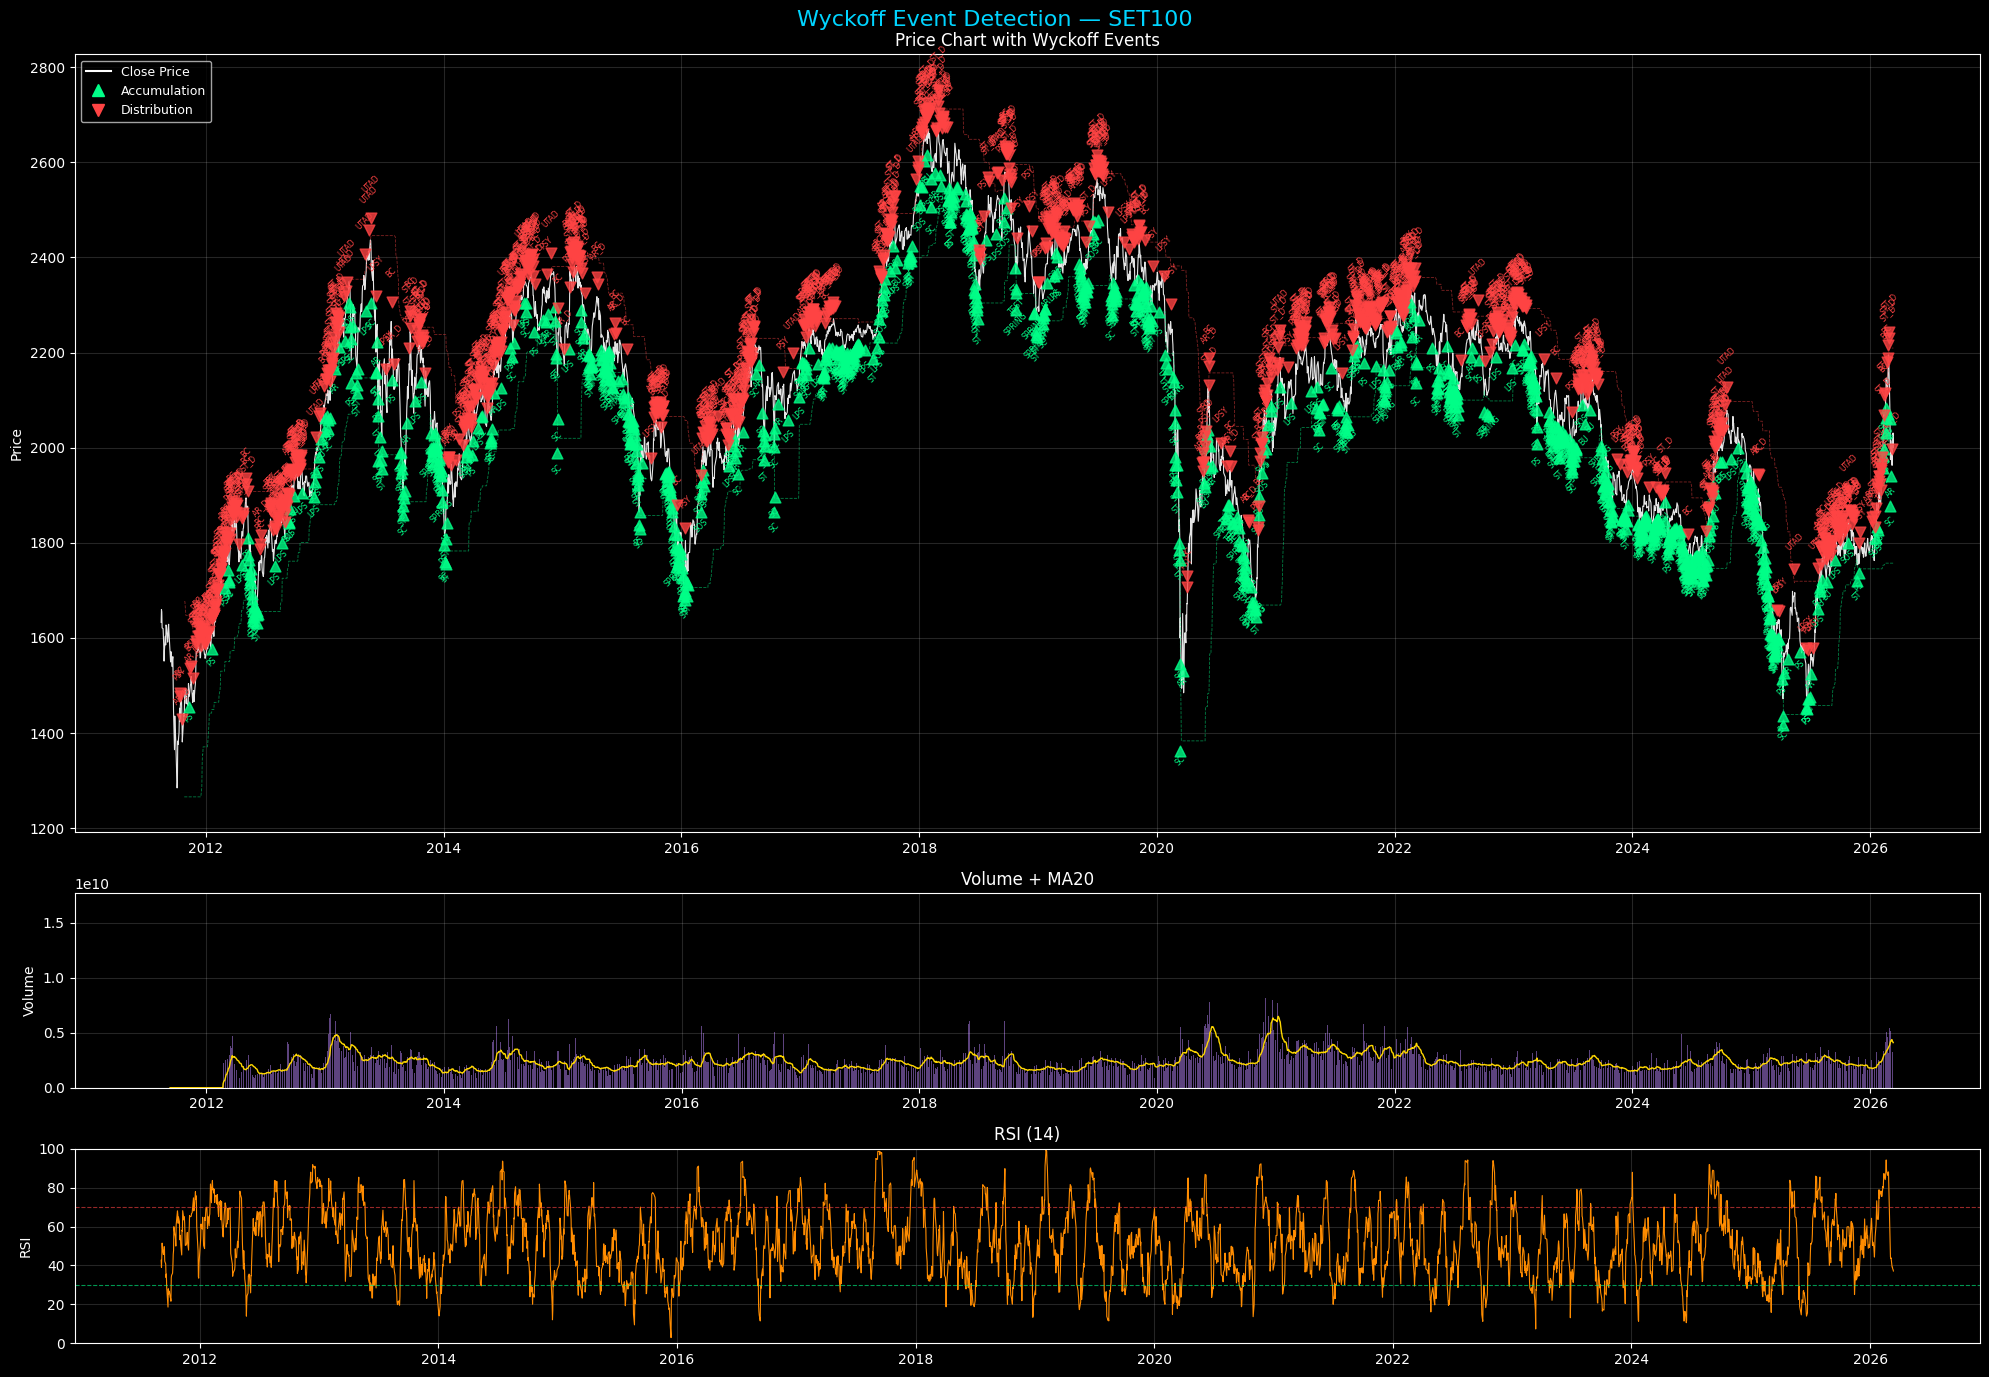

In [9]:
# ===== Visualize: Event Detection Chart =====
print('📈 กราฟ: Wyckoff Event Detection บน Price Chart')

df_events = df[df['Wyckoff_Event'] != ''].copy()

ACCUM_COLOR = '#00FF88'
DIST_COLOR  = '#FF4444'
MARKER_Y_OFFSET = 0.015

fig, axes = plt.subplots(3, 1, figsize=(20, 14), gridspec_kw={'height_ratios': [4, 1, 1]})
fig.suptitle('Wyckoff Event Detection — SET100', fontsize=16, color=COLORS['accent'])

# --- Price + Events ---
ax = axes[0]
ax.plot(df['Date'], df['Close'], color='white', linewidth=0.8, alpha=0.9, label='Close')
ax.plot(df['Date'], df['Support_TR'], color=COLORS['green'], linewidth=0.6,
        linestyle='--', alpha=0.5, label='Support TR')
ax.plot(df['Date'], df['Resistance_TR'], color=COLORS['red'], linewidth=0.6,
        linestyle='--', alpha=0.5, label='Resistance TR')

for event in ACCUM_EVENTS:
    ev_df = df[df['Wyckoff_Event'] == event]
    if len(ev_df) > 0:
        ax.scatter(ev_df['Date'], ev_df['Low'] * (1 - MARKER_Y_OFFSET),
                   marker='^', s=60, color=ACCUM_COLOR, alpha=0.8, zorder=5)
        for _, row in ev_df.iterrows():
            ax.annotate(event, (row['Date'], row['Low'] * (1 - MARKER_Y_OFFSET * 2.5)),
                        fontsize=5.5, color=ACCUM_COLOR, ha='center', rotation=45)

for event in DIST_EVENTS:
    ev_df = df[df['Wyckoff_Event'] == event]
    if len(ev_df) > 0:
        ax.scatter(ev_df['Date'], ev_df['High'] * (1 + MARKER_Y_OFFSET),
                   marker='v', s=60, color=DIST_COLOR, alpha=0.8, zorder=5)
        for _, row in ev_df.iterrows():
            ax.annotate(event, (row['Date'], row['High'] * (1 + MARKER_Y_OFFSET * 2.5)),
                        fontsize=5.5, color=DIST_COLOR, ha='center', rotation=45)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='white', label='Close Price'),
    Line2D([0],[0], marker='^', color=ACCUM_COLOR, linestyle='None', markersize=8, label='Accumulation'),
    Line2D([0],[0], marker='v', color=DIST_COLOR,  linestyle='None', markersize=8, label='Distribution'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_ylabel('Price')
ax.grid(alpha=0.15)
ax.set_title('Price Chart with Wyckoff Events', color='white')

# --- Volume ---
axes[1].bar(df['Date'], df['Volume'], color=COLORS['purple'], alpha=0.5, width=1)
axes[1].plot(df['Date'], df['Vol_MA20'], color=COLORS['yellow'], linewidth=1)
axes[1].set_ylabel('Volume')
axes[1].set_title('Volume + MA20', color='white')
axes[1].grid(alpha=0.15)

# --- RSI ---
axes[2].plot(df['Date'], df['RSI'], color=COLORS['orange'], linewidth=0.8)
axes[2].axhline(70, color=COLORS['red'],   linestyle='--', alpha=0.6, linewidth=0.8)
axes[2].axhline(30, color=COLORS['green'], linestyle='--', alpha=0.6, linewidth=0.8)
axes[2].set_ylabel('RSI')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (14)', color='white')
axes[2].grid(alpha=0.15)

plt.tight_layout()
plt.show()

---
## 🤖 Phase 4: Modeling — Part 1: Event Label Classification

In [10]:
# ===== CRISP-DM Phase 4: Part 1 — Event Label Classification =====
print("="*70)
print("   CRISP-DM Phase 4: MODELING")
print("   Part 1: Wyckoff Event Label Classification")
print("="*70)

# กรองเฉพาะแถวที่มี Event
df_labeled = df[df['Wyckoff_Event'] != ''].copy()
df_labeled = df_labeled.dropna(subset=ML_FEATURES)

# ตัด event น้อยกว่า 5
event_counts = df_labeled['Wyckoff_Event'].value_counts()
valid_events = event_counts[event_counts >= 5].index
df_labeled = df_labeled[df_labeled['Wyckoff_Event'].isin(valid_events)].copy()

print('\n📊 ตาราง: Event Distribution ก่อน Modeling')
ev_dist = pd.DataFrame({
    'Event': event_counts.index[:20],
    'Count': event_counts.values[:20],
    'Pct (%)': (event_counts.values[:20] / event_counts.sum() * 100).round(2),
    'Phase': [df[df['Wyckoff_Event']==e]['Wyckoff_Phase'].mode()[0]
              if len(df[df['Wyckoff_Event']==e]) > 0 else '' for e in event_counts.index[:20]]
})
display(ev_dist)

# Encode labels
le = LabelEncoder()
df_labeled['y_encoded'] = le.fit_transform(df_labeled['Wyckoff_Event'])

print(f'\n✅ Classes ทั้งหมด: {list(le.classes_)}')
print(f'   จำนวน: {len(df_labeled):,} samples | {len(le.classes_)} classes')

X = df_labeled[ML_FEATURES].values
y = df_labeled['y_encoded'].values

# SMOTE
min_count = np.unique(y, return_counts=True)[1].min()
if HAS_SMOTE and min_count >= 6:
    k_neighbors = min(5, min_count - 1)
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_res, y_res = smote.fit_resample(X, y)
    print(f'\n✅ SMOTE: {len(X):,} → {len(X_res):,} samples')
else:
    X_res, y_res = X, y
    print('⚠️  ข้าม SMOTE')

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

scaler1 = StandardScaler()
X_train_s = scaler1.fit_transform(X_train)
X_test_s  = scaler1.transform(X_test)

print(f'\n📊 ตาราง: Data Split Summary')
split_df = pd.DataFrame({
    'Set': ['Train','Test','Total'],
    'Samples': [len(X_train), len(X_test), len(X_train)+len(X_test)],
    'Pct (%)': [80.0, 20.0, 100.0]
})
display(split_df)

   CRISP-DM Phase 4: MODELING
   Part 1: Wyckoff Event Label Classification

📊 ตาราง: Event Distribution ก่อน Modeling


,Event,Count,Pct (%),Phase
0,ST_D,781,37.2800,Distribution
1,ST,556,26.5400,Accumulation
2,BC,160,7.6400,Distribution
3,SC,119,5.6800,Accumulation
4,PS,73,3.4800,Accumulation
5,PSY,64,3.0500,Distribution
6,SOS,61,2.9100,Accumulation
7,AR_D,57,2.7200,Distribution
8,AR,57,2.7200,Accumulation
9,LPS,39,1.8600,Accumulation



✅ Classes ทั้งหมด: ['AR', 'AR_D', 'BC', 'BU', 'LPS', 'LPSY', 'PS', 'PSY', 'SC', 'SOS', 'SPRING', 'ST', 'ST_D', 'TEST', 'UTAD']
   จำนวน: 2,094 samples | 15 classes

✅ SMOTE: 2,094 → 11,715 samples

📊 ตาราง: Data Split Summary


,Set,Samples,Pct (%)
0,Train,9372,80.0000
1,Test,2343,20.0000
2,Total,11715,100.0000


In [ ]:
# ===== Part 1: เทรนโมเดลทั้งหมด =====
print('🔄 กำลังเทรนโมเดล Part 1...')

models_p1 = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=2,
        random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boost': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42),
    'Logistic Reg': LogisticRegression(
        max_iter=2000, 
        C=1.0, 
        random_state=42, 
        # ลบ multi_class='auto' ออก
        class_weight='balanced'
    ),
}
if HAS_XGB:
    models_p1['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, verbosity=0)

results_p1 = {}
for name, model in models_p1.items():
    Xtr = X_train_s if 'Logistic' in name else X_train
    Xte = X_test_s  if 'Logistic' in name else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_wt  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cv     = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    results_p1[name] = {
        'model':    model,
        'accuracy': acc,
        'f1_macro': f1_mac,
        'f1_weighted': f1_wt,
        'cv_mean':  cv.mean(),
        'cv_std':   cv.std(),
        'y_pred':   y_pred,
    }
    print(f'  ✅ {name:20s} | Acc={acc:.4f} | F1(wt)={f1_wt:.4f} | CV={cv.mean():.4f}±{cv.std():.4f}')

best_p1 = max(results_p1, key=lambda k: results_p1[k]['accuracy'])
print(f'\n🏆 Best Model (Part 1): {best_p1} (Acc={results_p1[best_p1]["accuracy"]:.4f})')



🔄 กำลังเทรนโมเดล Part 1...
  ✅ Random Forest        | Acc=0.9731 | F1(wt)=0.9722 | CV=0.9639±0.0034
  ✅ Gradient Boost       | Acc=0.9740 | F1(wt)=0.9734 | CV=0.9649±0.0034
  ✅ Logistic Reg         | Acc=0.8395 | F1(wt)=0.8325 | CV=0.8399±0.0073
  ✅ XGBoost              | Acc=0.9795 | F1(wt)=0.9791 | CV=0.9754±0.0040

🏆 Best Model (Part 1): XGBoost (Acc=0.9795)

📊 ตาราง: Model Comparison — Part 1 (Event Label Classification)


,Model,Test Accuracy,F1 Macro,F1 Weighted,CV Mean,CV Std,Best
0,Random Forest,0.9731,0.9723,0.9722,0.9639,0.0034,
1,Gradient Boost,0.9740,0.9735,0.9734,0.9649,0.0034,
2,Logistic Reg,0.8395,0.8327,0.8325,0.8399,0.0073,
3,XGBoost,0.9795,0.9792,0.9791,0.9754,0.0040,⭐


📊 ตาราง: Classification Report — XGBoost


,precision,recall,f1-score,support
AR,0.9745,0.9808,0.9776,156.0000
AR_D,0.9625,0.9872,0.9747,156.0000
BC,0.9872,0.9872,0.9872,156.0000
BU,0.9623,0.9745,0.9684,157.0000
LPS,0.9811,1.0000,0.9905,156.0000
LPSY,1.0000,1.0000,1.0000,156.0000
PS,1.0000,1.0000,1.0000,157.0000
PSY,1.0000,0.9936,0.9968,156.0000
SC,1.0000,1.0000,1.0000,156.0000
SOS,0.9873,1.0000,0.9936,156.0000


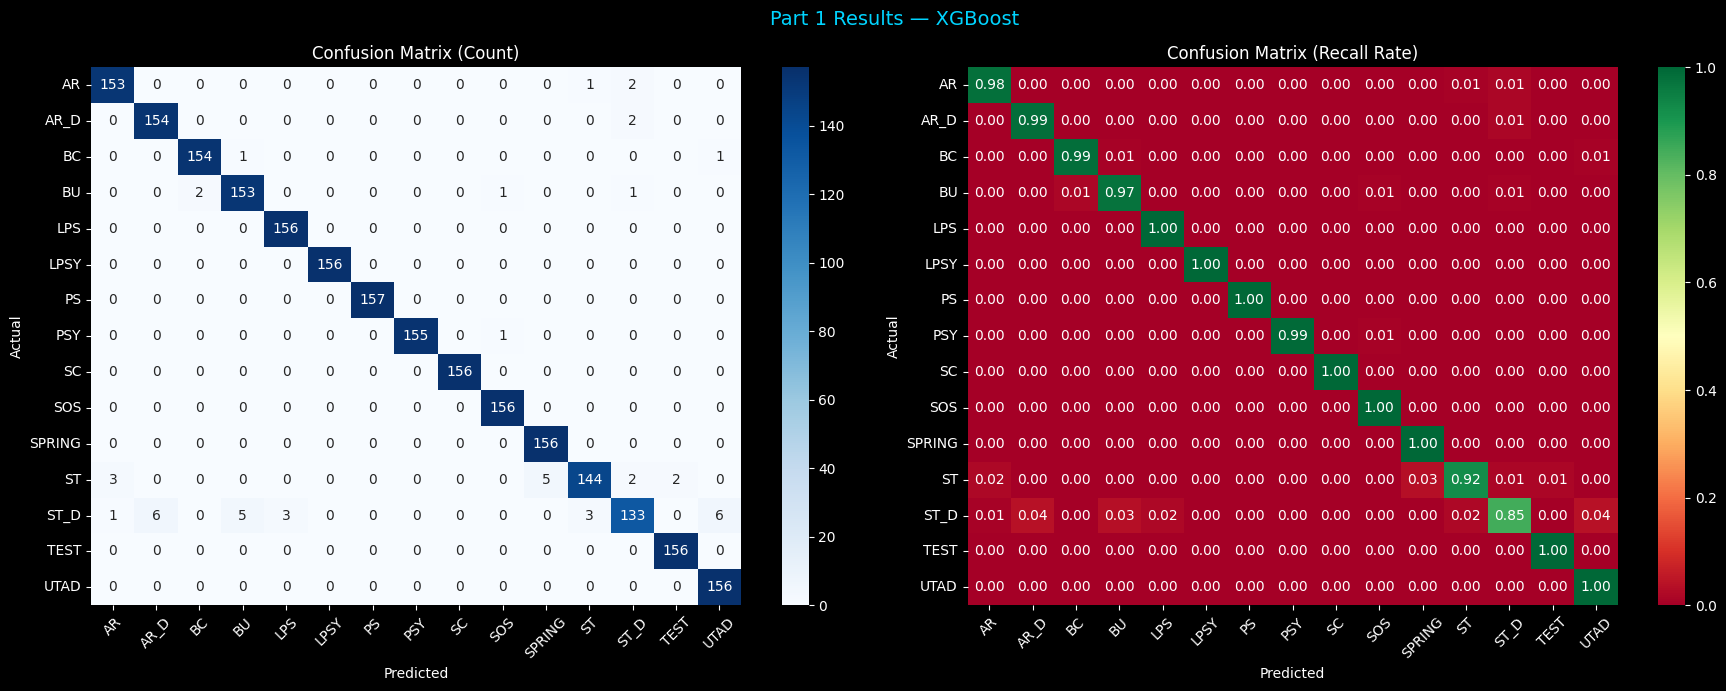

In [22]:
# ===== Part 1: Classification Report & Confusion Matrix =====
best = results_p1[best_p1]
y_pred_best = best['y_pred']

print(f'📊 ตาราง: Classification Report — {best_p1}')
cr = classification_report(y_test, y_pred_best,
     target_names=le.classes_, output_dict=True, zero_division=0)
cr_df = pd.DataFrame(cr).T.round(4)
display(cr_df)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Part 1 Results — {best_p1}', fontsize=14, color=COLORS['accent'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)', color='white')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (Recall Rate)', color='white')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

📊 ตาราง: Feature Importance — XGBoost


,Rank,Feature,Importance,Pct (%)
0,1,Close_Pos,0.1221,12.2100
1,2,TR_Position,0.1122,11.2200
2,3,Rel_Vol,0.1078,10.7800
3,4,Dist_from_Sup,0.0864,8.6300
4,5,Is_Bullish,0.0734,7.3400
5,6,Dist_from_Res,0.0723,7.2300
6,7,Price_Trend,0.0480,4.8000
7,8,Return_1d,0.0402,4.0200
8,9,Return_5d,0.0372,3.7200
9,10,Price_vs_MA50,0.0360,3.6000


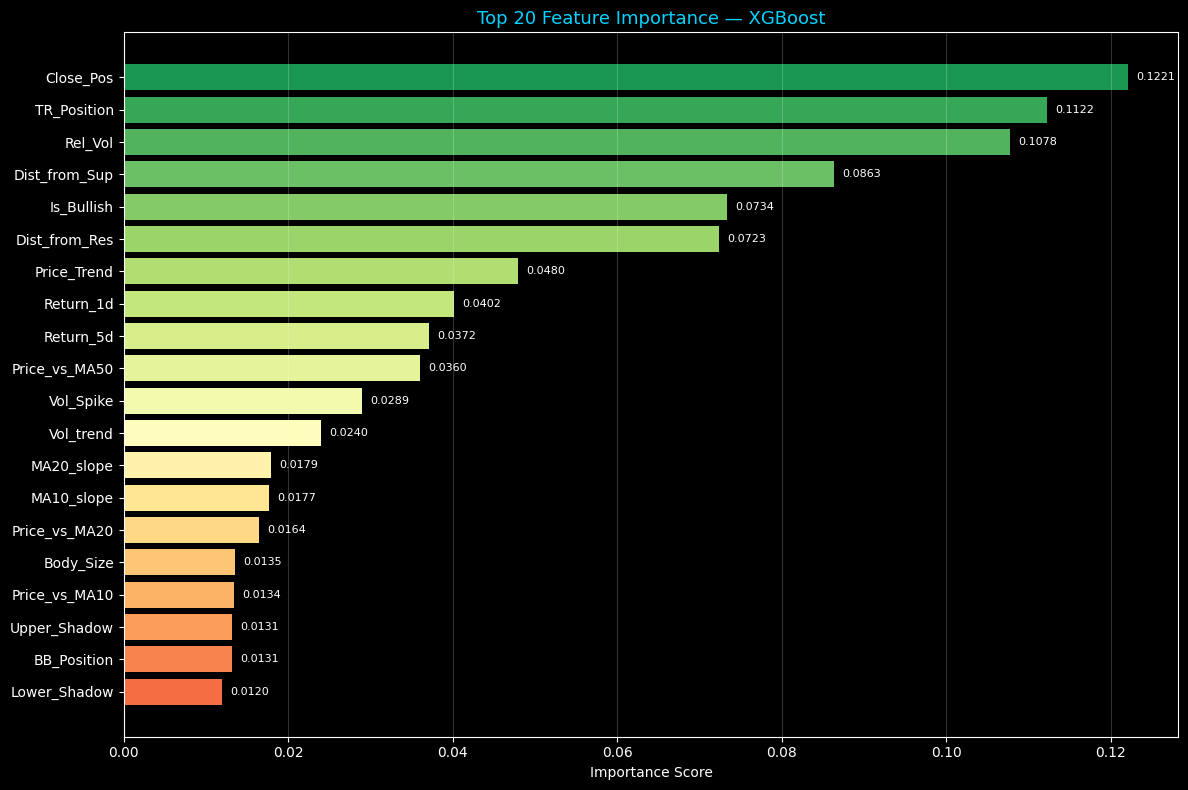

In [13]:
# ===== Part 1: Feature Importance =====
best_model_p1 = best['model']

if hasattr(best_model_p1, 'feature_importances_'):
    importances = best_model_p1.feature_importances_
    feat_imp = pd.DataFrame({'Feature': ML_FEATURES, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False).reset_index(drop=True)
    feat_imp['Rank'] = range(1, len(feat_imp)+1)
    feat_imp['Pct (%)'] = (feat_imp['Importance'] / feat_imp['Importance'].sum() * 100).round(2)

    print(f'📊 ตาราง: Feature Importance — {best_p1}')
    display(feat_imp[['Rank','Feature','Importance','Pct (%)']].round(6))

    # Plot
    top_n = 20
    top_feat = feat_imp.head(top_n)
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, top_n)[::-1])

    plt.figure(figsize=(12, 8))
    bars = plt.barh(top_feat['Feature'], top_feat['Importance'], color=colors_fi)
    for bar, val in zip(bars, top_feat['Importance']):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8, color='white')
    plt.xlabel('Importance Score')
    plt.title(f'Top {top_n} Feature Importance — {best_p1}', fontsize=13, color=COLORS['accent'])
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

---
## 📈 Phase 4: Modeling — Part 2: Return Direction Prediction

In [14]:
# ===== Part 2: Return Direction Prediction =====
print("="*70)
print("   CRISP-DM Phase 4: MODELING")
print("   Part 2: Return Direction Prediction (10-day Forward)")
print("="*70)

FORWARD_DAYS = 10

df['Future_Return']    = df['Close'].shift(-FORWARD_DAYS) / df['Close'] - 1
df['Target_Direction'] = (df['Future_Return'] > 0).astype(int)

df_p2 = df.dropna(subset=ML_FEATURES + ['Target_Direction', 'Future_Return']).copy()

print(f'\n✅ ข้อมูล Part 2: {len(df_p2):,} แถว | ทำนาย {FORWARD_DAYS} วันล่วงหน้า')

print('\n📊 ตาราง: Target Distribution')
tgt = df_p2['Target_Direction'].value_counts()
tgt_df = pd.DataFrame({
    'Direction': ['ขึ้น (1)','ลง (0)'],
    'Count': [tgt.get(1,0), tgt.get(0,0)],
    'Pct (%)': [(tgt.get(1,0)/len(df_p2)*100).round(2),
                (tgt.get(0,0)/len(df_p2)*100).round(2)]
})
display(tgt_df)
print(f'   Baseline Accuracy (predict majority): {tgt.max()/len(df_p2):.4f}')

# Time-series split (ไม่ random — เพื่อไม่ให้ data leakage)
split_idx = int(len(df_p2) * 0.80)
df_train_p2 = df_p2.iloc[:split_idx].copy()
df_test_p2  = df_p2.iloc[split_idx:].copy()

X_train_p2 = df_train_p2[ML_FEATURES].values
y_train_p2 = df_train_p2['Target_Direction'].values
X_test_p2  = df_test_p2[ML_FEATURES].values
y_test_p2  = df_test_p2['Target_Direction'].values

scaler2 = StandardScaler()
X_train_p2_s = scaler2.fit_transform(X_train_p2)
X_test_p2_s  = scaler2.transform(X_test_p2)

print(f'\n📊 ตาราง: Time-Series Split (ไม่สุ่ม เพื่อป้องกัน Data Leakage)')
ts_split = pd.DataFrame({
    'Set': ['Train','Test'],
    'Samples': [len(X_train_p2), len(X_test_p2)],
    'Date From': [df_train_p2['Date'].min().date(), df_test_p2['Date'].min().date()],
    'Date To':   [df_train_p2['Date'].max().date(), df_test_p2['Date'].max().date()],
})
display(ts_split)

   CRISP-DM Phase 4: MODELING
   Part 2: Return Direction Prediction (10-day Forward)

✅ ข้อมูล Part 2: 3,494 แถว | ทำนาย 10 วันล่วงหน้า

📊 ตาราง: Target Distribution


,Direction,Count,Pct (%)
0,ขึ้น (1),1817,52.0000
1,ลง (0),1677,48.0000


   Baseline Accuracy (predict majority): 0.5200

📊 ตาราง: Time-Series Split (ไม่สุ่ม เพื่อป้องกัน Data Leakage)


,Set,Samples,Date From,Date To
0,Train,2795,2011-10-26,2023-04-11
1,Test,699,2023-04-12,2026-02-26


In [15]:
# ===== Part 2: เทรนโมเดล =====
print('🔄 กำลังเทรนโมเดล Part 2...')

models_p2 = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=3,
        random_state=42, n_jobs=-1),
    'Gradient Boost': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42),
    'Logistic Reg': LogisticRegression(
        max_iter=2000, C=0.1, random_state=42),
}
if HAS_XGB:
    models_p2['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0)

results_p2 = {}
for name, model in models_p2.items():
    Xtr = X_train_p2_s if 'Logistic' in name else X_train_p2
    Xte = X_test_p2_s  if 'Logistic' in name else X_test_p2

    model.fit(Xtr, y_train_p2)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    acc = accuracy_score(y_test_p2, y_pred)
    auc = roc_auc_score(y_test_p2, y_prob)
    f1  = f1_score(y_test_p2, y_pred, zero_division=0)

    results_p2[name] = {
        'model': model, 'acc': acc, 'auc': auc, 'f1': f1,
        'y_pred': y_pred, 'y_prob': y_prob,
    }
    print(f'  ✅ {name:20s} | Acc={acc:.4f} | AUC={auc:.4f} | F1={f1:.4f}')

best_p2 = max(results_p2, key=lambda k: results_p2[k]['auc'])
print(f'\n🏆 Best Model (Part 2 by AUC): {best_p2}')

print('\n📊 ตาราง: Model Comparison — Part 2 (Return Direction Prediction)')
comp2 = pd.DataFrame([
    {'Model': n, 'Accuracy': f"{v['acc']:.4f}", 'AUC-ROC': f"{v['auc']:.4f}",
     'F1 Score': f"{v['f1']:.4f}", 'Best': '⭐' if n == best_p2 else ''}
    for n, v in results_p2.items()
])
display(comp2)

🔄 กำลังเทรนโมเดล Part 2...
  ✅ Random Forest        | Acc=0.4649 | AUC=0.4353 | F1=0.4580
  ✅ Gradient Boost       | Acc=0.4821 | AUC=0.4711 | F1=0.5068
  ✅ Logistic Reg         | Acc=0.4664 | AUC=0.4958 | F1=0.5355
  ✅ XGBoost              | Acc=0.4735 | AUC=0.4530 | F1=0.4875

🏆 Best Model (Part 2 by AUC): Logistic Reg

📊 ตาราง: Model Comparison — Part 2 (Return Direction Prediction)


,Model,Accuracy,AUC-ROC,F1 Score,Best
0,Random Forest,0.4649,0.4353,0.4580,
1,Gradient Boost,0.4821,0.4711,0.5068,
2,Logistic Reg,0.4664,0.4958,0.5355,⭐
3,XGBoost,0.4735,0.4530,0.4875,


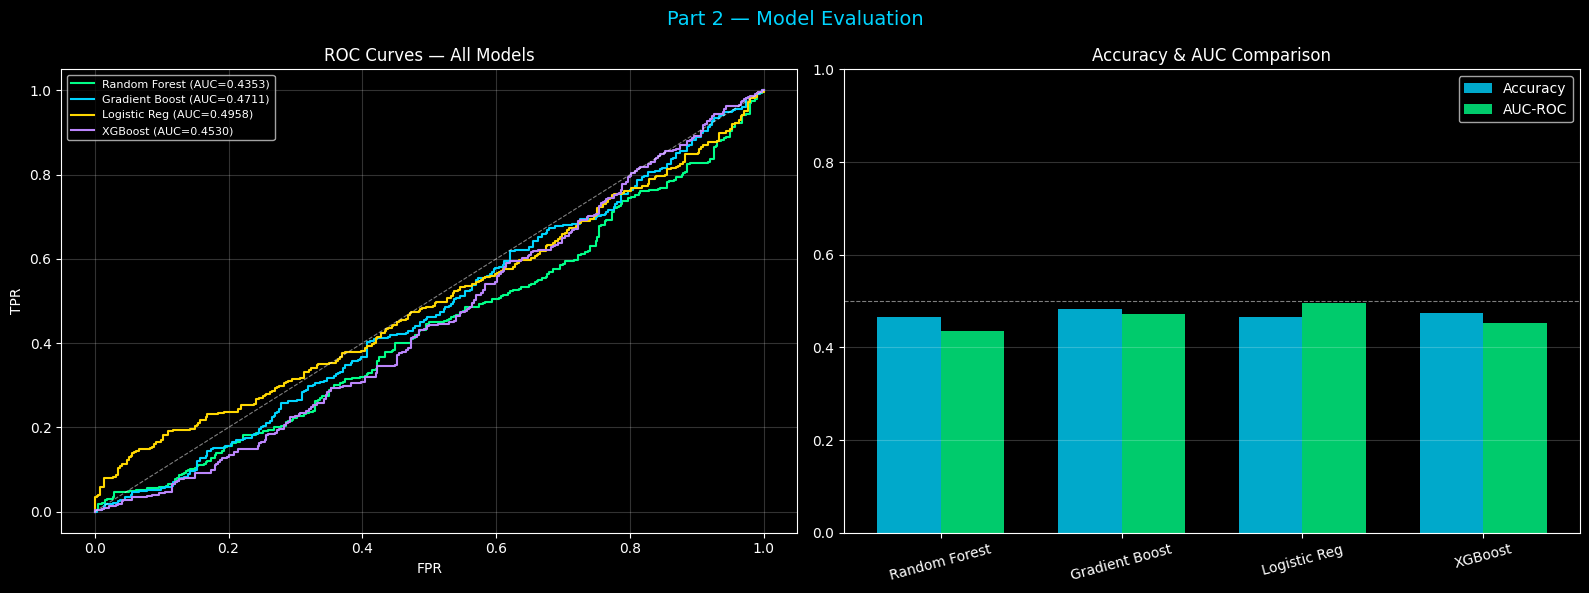

In [16]:
# ===== Part 2: ROC Curve =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Part 2 — Model Evaluation', fontsize=14, color=COLORS['accent'])

colors_roc = [COLORS['green'], COLORS['accent'], COLORS['yellow'], COLORS['purple']]

for (name, v), color in zip(results_p2.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test_p2, v['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.4f})", color=color, linewidth=1.5)

axes[0].plot([0,1],[0,1], 'w--', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# Bar comparison
names = list(results_p2.keys())
accs  = [results_p2[n]['acc'] for n in names]
aucs  = [results_p2[n]['auc'] for n in names]
x = np.arange(len(names))
w = 0.35
axes[1].bar(x - w/2, accs, w, label='Accuracy', color=COLORS['accent'], alpha=0.8)
axes[1].bar(x + w/2, aucs, w, label='AUC-ROC',  color=COLORS['green'],  alpha=0.8)
axes[1].axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15)
axes[1].set_ylim(0, 1)
axes[1].set_title('Accuracy & AUC Comparison')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [30]:
# ===== Part 2: Win Rate แยกตาม Wyckoff Event =====
print("="*70)
print("   OUTPUT: Win Rate Analysis by Wyckoff Event")
print("="*70)

best_model_p2 = results_p2[best_p2]['model']
Xte_p2 = X_test_p2_s if 'Logistic' in best_p2 else X_test_p2

df_test_p2c = df_test_p2.copy()
df_test_p2c['ML_Pred']      = best_model_p2.predict(Xte_p2)
df_test_p2c['ML_Prob']      = best_model_p2.predict_proba(Xte_p2)[:, 1]
df_test_p2c['ML_Correct']   = (df_test_p2c['ML_Pred'] == df_test_p2c['Target_Direction'])
df_test_p2c['Return_Category'] = pd.cut(df_test_p2c['Future_Return'],
    bins=[-np.inf, -0.05, -0.02, 0, 0.02, 0.05, np.inf],
    labels=['<-5%','-5~-2%','-2~0%','0~2%','2~5%','>5%'])

# Win rate by event
event_mask = df_test_p2c['Wyckoff_Event'] != ''
event_perf = df_test_p2c[event_mask].groupby('Wyckoff_Event').agg(
    Count       = ('ML_Correct', 'count'),
    Win_Rate    = ('ML_Correct', 'mean'),
    Actual_Up_Rate = ('Target_Direction', 'mean'),
    Avg_Return  = ('Future_Return', 'mean'),
    Std_Return  = ('Future_Return', 'std'),
    Avg_Prob    = ('ML_Prob', 'mean'),
).sort_values('Win_Rate', ascending=False)

event_perf['Phase'] = [
    df[df['Wyckoff_Event']==e]['Wyckoff_Phase'].mode()[0]
    if len(df[df['Wyckoff_Event']==e]) > 0 else ''
    for e in event_perf.index
]
event_perf['Signal'] = event_perf.apply(
    lambda r: '🟢 Strong' if r['Win_Rate'] >= 0.6 else
              '🟡 Moderate' if r['Win_Rate'] >= 0.5 else '🔴 Weak', axis=1)

print(f'\n📊 ตาราง: Win Rate แยกตาม Wyckoff Event ({FORWARD_DAYS}-day forward) — {best_p2}')
display(event_perf.round(4))


   OUTPUT: Win Rate Analysis by Wyckoff Event

📊 ตาราง: Win Rate แยกตาม Wyckoff Event (10-day forward) — Logistic Reg


,Count,Win_Rate,Actual_Up_Rate,Avg_Return,Std_Return,Avg_Prob,Phase,Signal
Wyckoff_Event,,,,,,,,
BU,10,0.7000,0.6000,0.0073,0.0416,0.5767,Accumulation,🟢 Strong
SPRING,3,0.6667,0.0000,-0.0327,0.0117,0.4913,Accumulation,🟢 Strong
BC,24,0.6250,0.5417,-0.0001,0.0361,0.5578,Distribution,🟢 Strong
ST_D,132,0.6061,0.5379,0.0074,0.0345,0.5247,Distribution,🟢 Strong
LPS,5,0.6000,0.4000,0.0073,0.0233,0.5519,Accumulation,🟢 Strong
SOS,17,0.5882,0.5882,0.0075,0.0429,0.6190,Accumulation,🟡 Moderate
PS,17,0.5294,0.5294,0.0044,0.0315,0.5422,Accumulation,🟡 Moderate
AR,14,0.5000,0.5714,0.0012,0.0378,0.6212,Accumulation,🟡 Moderate
ST,205,0.4341,0.4927,-0.0014,0.0256,0.5396,Accumulation,🔴 Weak


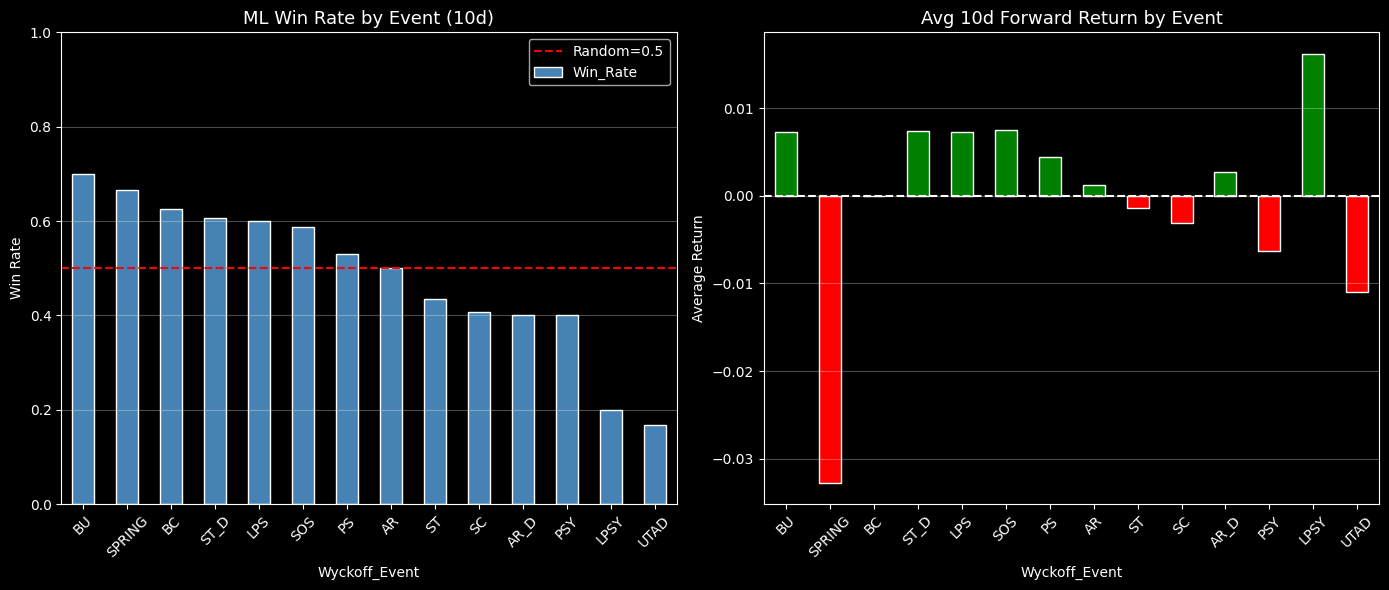

In [36]:
# ===== Part 2: วิเคราะห์ผลลัพธ์แยกตาม Wyckoff Event =====

best_model_p2 = results_p2[best_p2]['model']
Xte_p2 = X_test_p2_s if 'Logistic' in best_p2 else X_test_p2

df_test_p2_copy = df_test_p2.copy()
df_test_p2_copy['Predicted'] = best_model_p2.predict(Xte_p2)
df_test_p2_copy['Correct']   = (df_test_p2_copy['Predicted'] == df_test_p2_copy['Target_Direction'])

# Plot
if len(event_perf) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    event_perf['Win_Rate'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].axhline(0.5, color='red', linestyle='--', label='Random=0.5')
    axes[0].set_title(f'ML Win Rate by Event ({FORWARD_DAYS}d)', fontsize=13)
    axes[0].set_ylabel('Win Rate')
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    event_perf['Avg_Return'].plot(kind='bar', ax=axes[1],
        color=['green' if v > 0 else 'red' for v in event_perf['Avg_Return']],
        edgecolor='white')
    axes[1].axhline(0, color='white', linestyle='--')
    axes[1].set_title(f'Avg {FORWARD_DAYS}d Forward Return by Event', fontsize=13)
    axes[1].set_ylabel('Average Return')

    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

   Part 2: Backtest — ML Signal Strategy vs Buy & Hold

📊 ตาราง: Backtest Performance Metrics


,Strategy,Total Return (%),Sharpe Ratio,Max Drawdown (%),Avg Daily Return (%)
0,Buy & Hold,1.9600,0.1222,-31.9700,0.0075
1,ML Signal (Logistic Reg),11.6500,0.3561,-21.5500,0.0196
2,ML Strong (prob>0.55),26.2600,0.7707,-18.2300,0.0361


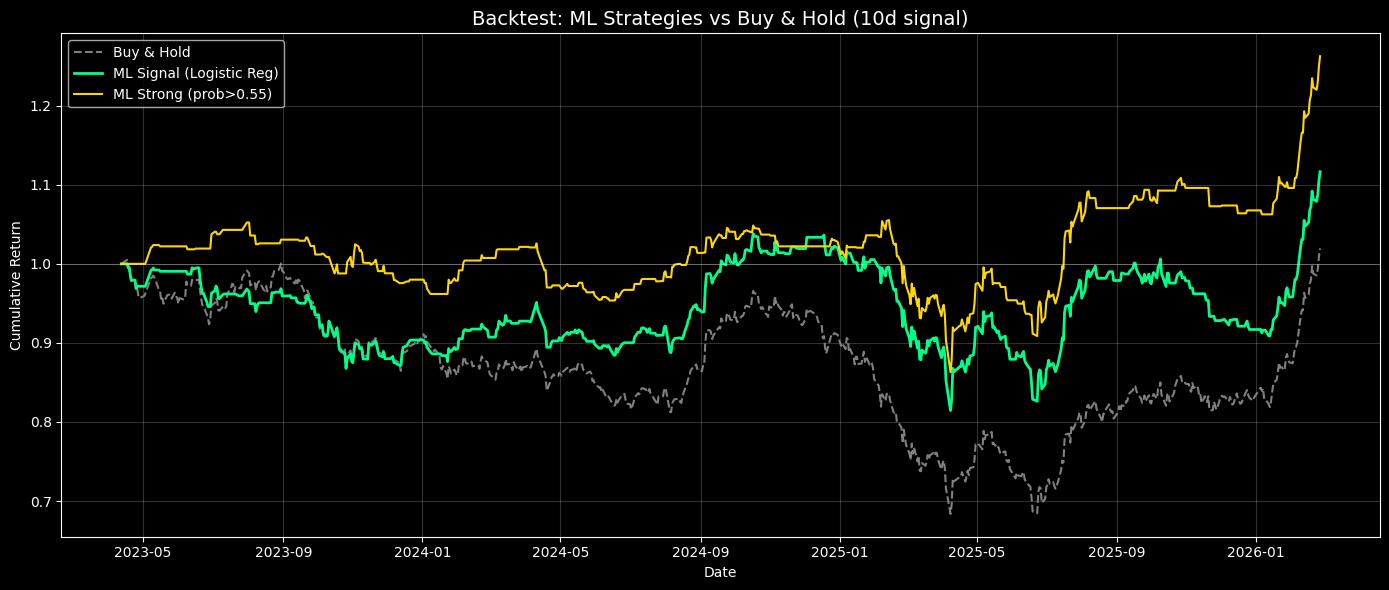

In [18]:
# ===== Part 2: Backtest Strategy =====
print("="*70)
print("   Part 2: Backtest — ML Signal Strategy vs Buy & Hold")
print("="*70)

df_bt = df_test_p2.copy()
df_bt['ML_Signal']    = results_p2[best_p2]['y_pred']
df_bt['ML_Prob']      = results_p2[best_p2]['y_prob']
df_bt['Daily_Return'] = df_bt['Close'].pct_change().fillna(0)

# Signal strength filter: ถือเมื่อ prob > threshold
PROB_THRESH = 0.55
df_bt['Strong_Signal'] = (df_bt['ML_Prob'] > PROB_THRESH).astype(int)

df_bt['Strategy_Return']  = df_bt['ML_Signal'].shift(1).fillna(0) * df_bt['Daily_Return']
df_bt['Strategy2_Return'] = df_bt['Strong_Signal'].shift(1).fillna(0) * df_bt['Daily_Return']

df_bt['Cum_BH']  = (1 + df_bt['Daily_Return']).cumprod()
df_bt['Cum_ML']  = (1 + df_bt['Strategy_Return']).cumprod()
df_bt['Cum_ML2'] = (1 + df_bt['Strategy2_Return']).cumprod()

# Metrics
def sharpe(returns, rf=0):
    excess = returns - rf/252
    return (excess.mean() / (excess.std() + 1e-10)) * np.sqrt(252)

def max_drawdown(cum_returns):
    roll_max = cum_returns.cummax()
    dd = (cum_returns - roll_max) / roll_max
    return dd.min()

metrics = pd.DataFrame({
    'Strategy': ['Buy & Hold', f'ML Signal ({best_p2})', f'ML Strong (prob>{PROB_THRESH})'],
    'Total Return (%)': [
        round((df_bt['Cum_BH'].iloc[-1]-1)*100, 2),
        round((df_bt['Cum_ML'].iloc[-1]-1)*100, 2),
        round((df_bt['Cum_ML2'].iloc[-1]-1)*100, 2),
    ],
    'Sharpe Ratio': [
        round(sharpe(df_bt['Daily_Return']), 4),
        round(sharpe(df_bt['Strategy_Return']), 4),
        round(sharpe(df_bt['Strategy2_Return']), 4),
    ],
    'Max Drawdown (%)': [
        round(max_drawdown(df_bt['Cum_BH'])*100, 2),
        round(max_drawdown(df_bt['Cum_ML'])*100, 2),
        round(max_drawdown(df_bt['Cum_ML2'])*100, 2),
    ],
    'Avg Daily Return (%)': [
        round(df_bt['Daily_Return'].mean()*100, 4),
        round(df_bt['Strategy_Return'].mean()*100, 4),
        round(df_bt['Strategy2_Return'].mean()*100, 4),
    ],
})

print('\n📊 ตาราง: Backtest Performance Metrics')
display(metrics)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_bt['Date'].values, df_bt['Cum_BH'].values,
         label='Buy & Hold', color='gray', linestyle='--', linewidth=1.5)
plt.plot(df_bt['Date'].values, df_bt['Cum_ML'].values,
         label=f'ML Signal ({best_p2})', color=COLORS['green'], linewidth=2)
plt.plot(df_bt['Date'].values, df_bt['Cum_ML2'].values,
         label=f'ML Strong (prob>{PROB_THRESH})', color=COLORS['yellow'], linewidth=1.5)
plt.axhline(1.0, color='white', linewidth=0.5, alpha=0.4)
plt.title(f'Backtest: ML Strategies vs Buy & Hold ({FORWARD_DAYS}d signal)', fontsize=14)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 📊 Phase 5: Evaluation — Walk-Forward Validation

   CRISP-DM Phase 5: EVALUATION
   Walk-Forward Validation (Time-Series Cross Validation)

📊 ตาราง: Walk-Forward Validation Results (Random Forest)


,Fold,Train Size,Test Size,Date From,Date To,Accuracy,AUC-ROC
0,1,584,584,2014-03-12,2016-08-08,0.5565,0.5482
1,2,1168,584,2016-08-09,2018-12-21,0.4966,0.4474
2,3,1752,584,2018-12-24,2021-05-21,0.4897,0.4844
3,4,2336,584,2021-05-24,2023-10-17,0.4384,0.4333
4,5,2920,584,2023-10-18,2026-03-13,0.4897,0.4612



📊 ตาราง: Walk-Forward Summary


,Metric,Mean,Std,Min,Max
0,Accuracy,0.4942,0.0420,0.4384,0.5565
1,AUC-ROC,0.4749,0.0451,0.4333,0.5482


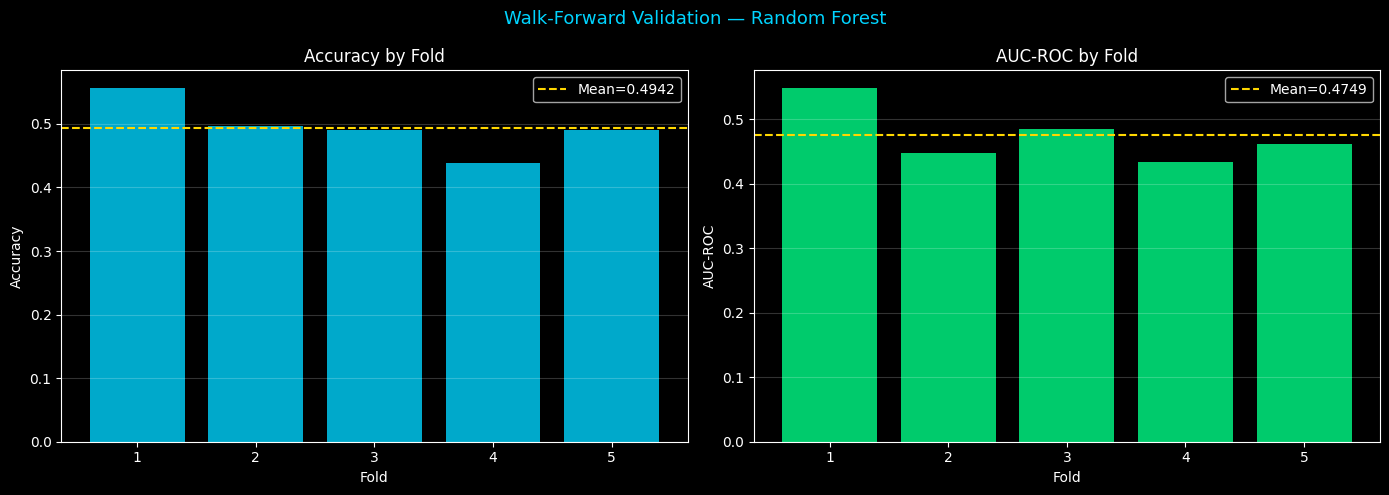

In [19]:
# ===== Walk-Forward Validation =====
print("="*70)
print("   CRISP-DM Phase 5: EVALUATION")
print("   Walk-Forward Validation (Time-Series Cross Validation)")
print("="*70)

df_wf = df.dropna(subset=ML_FEATURES + ['Target_Direction']).copy()
X_wf = df_wf[ML_FEATURES].values
y_wf = df_wf['Target_Direction'].values

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

wf_model = RandomForestClassifier(n_estimators=200, max_depth=8,
                                   random_state=42, n_jobs=-1)
wf_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_wf), 1):
    X_tr, X_te = X_wf[train_idx], X_wf[test_idx]
    y_tr, y_te = y_wf[train_idx], y_wf[test_idx]
    wf_model.fit(X_tr, y_tr)
    y_pr = wf_model.predict(X_te)
    y_pb = wf_model.predict_proba(X_te)[:,1]
    acc  = accuracy_score(y_te, y_pr)
    auc  = roc_auc_score(y_te, y_pb)
    date_from = df_wf.iloc[test_idx[0]]['Date'].date()
    date_to   = df_wf.iloc[test_idx[-1]]['Date'].date()
    wf_results.append({'Fold': fold, 'Train Size': len(train_idx),
                       'Test Size': len(test_idx),
                       'Date From': date_from, 'Date To': date_to,
                       'Accuracy': round(acc,4), 'AUC-ROC': round(auc,4)})

wf_df = pd.DataFrame(wf_results)
print('\n📊 ตาราง: Walk-Forward Validation Results (Random Forest)')
display(wf_df)

print('\n📊 ตาราง: Walk-Forward Summary')
wf_summary = pd.DataFrame({
    'Metric': ['Accuracy','AUC-ROC'],
    'Mean': [wf_df['Accuracy'].mean().round(4), wf_df['AUC-ROC'].mean().round(4)],
    'Std':  [wf_df['Accuracy'].std().round(4),  wf_df['AUC-ROC'].std().round(4)],
    'Min':  [wf_df['Accuracy'].min(), wf_df['AUC-ROC'].min()],
    'Max':  [wf_df['Accuracy'].max(), wf_df['AUC-ROC'].max()],
})
display(wf_summary)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Walk-Forward Validation — Random Forest', fontsize=13, color=COLORS['accent'])

axes[0].bar(wf_df['Fold'], wf_df['Accuracy'], color=COLORS['accent'], alpha=0.8)
axes[0].axhline(wf_df['Accuracy'].mean(), color=COLORS['yellow'], linestyle='--',
                label=f"Mean={wf_df['Accuracy'].mean():.4f}")
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by Fold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.2)

axes[1].bar(wf_df['Fold'], wf_df['AUC-ROC'], color=COLORS['green'], alpha=0.8)
axes[1].axhline(wf_df['AUC-ROC'].mean(), color=COLORS['yellow'], linestyle='--',
                label=f"Mean={wf_df['AUC-ROC'].mean():.4f}")
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC by Fold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

---
## 🖥️ Phase 6: Deployment — Research Dashboard

In [28]:
# ===== RESEARCH DASHBOARD — ตาราง Summary ก่อน =====
print("="*70)
print("   CRISP-DM Phase 6: DEPLOYMENT / REPORTING")
print("   Research Dashboard — Summary Tables")
print("="*70)

# ---- ตาราง 1: Event Statistics ----
print('\n📊 [TABLE 1] Complete Wyckoff Event Statistics')
all_ev = df[df['Wyckoff_Event'] != ''].copy()
ev_stats = all_ev.groupby(['Wyckoff_Phase','Wyckoff_Event']).agg(
    Count        = ('Date', 'count'),
    Avg_Rel_Vol  = ('Rel_Vol', 'mean'),
    Avg_Close_Pos= ('Close_Pos', 'mean'),
    Avg_RSI      = ('RSI', 'mean'),
    Avg_TR_Pos   = ('TR_Position', 'mean'),
    Avg_Spread   = ('Rel_Spread', 'mean'),
    Avg_Body     = ('Body_Size', 'mean'),
    Pct_Bullish  = ('Is_Bullish', 'mean'),
).round(4)
display(ev_stats)



   CRISP-DM Phase 6: DEPLOYMENT / REPORTING
   Research Dashboard — Summary Tables

📊 [TABLE 1] Complete Wyckoff Event Statistics


Count  Avg_Rel_Vol  Avg_Close_Pos  Avg_RSI  Avg_TR_Pos  Avg_Spread  Avg_Body  Pct_Bullish
Wyckoff_Phase Wyckoff_Event                                                                                           
Accumulation  AR                57       1.0261         0.5956  45.8967      0.5177      0.9432    0.3852       0.7018
              BU                37       1.1022         0.6990  73.9482      0.9418      1.0089    0.3546       0.7027
              LPS               39       0.7457         0.8611  59.8870      0.8104      0.9472    0.5259       0.9744
              PS                73       1.5384         0.0827  40.5025      0.3206      1.6637    0.7363       0.0000
              SC               119       1.5761         0.5578  39.9902      0.3500      1.5988    0.4206       0.4874
              SOS               61       1.5720         0.7605  79.6051      1.0968      1.2901    0.5703       0.9672
              SPRING            21       0.9732         0.7884  31.0714      0.0698      1.2245    0.4140       0.9048
              ST               556       0.9283         0.4536  37.1347      0.2051      1.0526    0.4721       0.3777
              TEST              18       0.7002         0.4153  35.7809      0.1557      0.9265    0.6200       0.3333
Distribution  AR_D              58       1.0242         0.3889  55.4061      0.6335      1.1553    0.4885       0.1897
              BC               161       1.6670         0.3433  65.0207      0.7765      1.0139    0.3996       0.3106
              LPSY              23       0.7269         0.1875  39.6364      0.2588      0.9397    0.5820       0.0870
              PSY               65       1.6697         0.9055  61.1608      0.7300      1.2158    0.6513       0.9846
              ST_D             781       0.9400         0.4906  62.8533      0.8335      0.9471    0.4378       0.4712
              UT                 1       1.0844         0.1229  66.8600      0.9554      0.7771    0.6050       0.0000
              UTAD              28       1.0115         0.2183  70.3151      0.9592      0.8821    0.3847       0.0000